# Final Evaluation & Error Analysis

This notebook compares the final model, `catboost_log_tuned` (v3, log1p target,
depth=8, l2_leaf_reg=3), against the strongest baseline,
`seasonal_naive_last_year`, on the long-horizon validation window
(train 2010-2013 -> validate 2014-2016).

It breaks the MAPE down by country / store / product / year and plots
the worst-performing (country, store, product) series, to support the
Results section of `project.pdf`.

Run this after `02_baselines.ipynb` and `03_model.ipynb` (both must have
already written their rows to `results/metrics.csv`).

## Reproducibility

Place `train.csv` and `test.csv` in `data/`. Install dependencies:

```bash
python -m pip install -r requirements.txt
```

Run all cells in order using this environment.

## 1. Imports

In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()
candidates = [
    current_dir,
    current_dir.parent,
    current_dir / "sticker-sales-forecasting",
]

PROJECT_ROOT = next(
    (
        path
        for path in candidates
        if (path / "src" / "preprocessing.py").is_file()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise RuntimeError(f"Project root not found from: {current_dir}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import load_data, preprocess_data, drop_missing_target
from src.features import add_date_features
from src.validation import expanding_window_splits, temporal_train_val_split
from src.metrics import mape
from src.model import fit_model, predict_model, FEATURE_COLS, CATEGORICAL_FEATURES, TARGET_COL
from src.baselines import seasonal_naive_predict

RESULTS_DIR = PROJECT_ROOT / "results"
BEST_MODEL_LABEL = "catboost_log_tuned (v3)"
BASELINE_LABEL = "seasonal_naive_last_year"
BEST_PARAMS = {"iterations": 500, "depth": 8, "learning_rate": 0.05, "l2_leaf_reg": 3}


## 2. Data preparation

In [2]:
train_raw, test_raw = load_data(
    PROJECT_ROOT / "data" / "train.csv",
    PROJECT_ROOT / "data" / "test.csv",
)

train = preprocess_data(train_raw)
train = drop_missing_target(train)
train = add_date_features(train)

print("Prepared feature matrix:", train[FEATURE_COLS].shape)


Prepared feature matrix: (221259, 18)


## 3. Recreate the long-horizon split and train the final model (v3)

Same split used by `03_model.ipynb`: train 2010-2013, validate 2014-2016.

In [3]:
long_train, long_val = temporal_train_val_split(
    train,
    val_start_date="2014-01-01",
)

# --- final model (v3) ---------------------------------------------------
v3_model = fit_model(long_train, params=BEST_PARAMS)
v3_predictions = predict_model(v3_model, long_val)

# --- strongest baseline --------------------------------------------------
baseline_predictions = seasonal_naive_predict(long_train, long_val)

y_true = long_val[TARGET_COL].to_numpy()

overall_model_mape = mape(y_true, v3_predictions)
overall_baseline_mape = mape(y_true, baseline_predictions)

print(f"[long-horizon] {BEST_MODEL_LABEL} MAPE = {overall_model_mape:.2f}%")
print(f"[long-horizon] {BASELINE_LABEL} MAPE = {overall_baseline_mape:.2f}%")


[long-horizon] catboost_log_tuned (v3) MAPE = 14.60%
[long-horizon] seasonal_naive_last_year MAPE = 17.02%


## 4. MAPE breakdown by country / store / product

In [4]:
def mape_by_group(y_true, y_pred_model, y_pred_baseline, groups, group_col):
    df = pd.DataFrame({
        "y_true": y_true,
        "y_pred_model": y_pred_model,
        "y_pred_baseline": y_pred_baseline,
        group_col: groups.to_numpy(),
    })

    def _agg(g):
        return pd.Series({
            f"mape_{BEST_MODEL_LABEL}": mape(g["y_true"], g["y_pred_model"]),
            f"mape_{BASELINE_LABEL}": mape(g["y_true"], g["y_pred_baseline"]),
        })

    out = df.groupby(group_col).apply(_agg).reset_index()
    out["gap"] = out[f"mape_{BASELINE_LABEL}"] - out[f"mape_{BEST_MODEL_LABEL}"]
    return out.sort_values(f"mape_{BEST_MODEL_LABEL}", ascending=False)


breakdowns = {}
for col in ["country", "store", "product"]:
    b = mape_by_group(y_true, v3_predictions, baseline_predictions, long_val[col], col)
    breakdowns[col] = b
    print(f"\n=== MAPE by {col} (worst first for the final model) ===")
    print(b.to_string(index=False))
    b.to_csv(RESULTS_DIR / f"error_analysis_by_{col}.csv", index=False)



=== MAPE by country (worst first for the final model) ===
  country  mape_catboost_log_tuned (v3)  mape_seasonal_naive_last_year       gap
   Norway                     30.810570                      25.972108 -4.838462
   Canada                     16.299779                      15.774065 -0.525714
    Italy                     11.882462                      15.430044  3.547581
  Finland                     11.873885                      13.353918  1.480034
    Kenya                     11.041705                      19.980707  8.939002
Singapore                      5.626298                      11.685417  6.059119

=== MAPE by store (worst first for the final model) ===
               store  mape_catboost_log_tuned (v3)  mape_seasonal_naive_last_year      gap
   Discount Stickers                     14.925477                      17.165251 2.239773
Premium Sticker Mart                     14.505421                      17.092429 2.587009
   Stickers for Less                     14.

## 5. MAPE by year within the long-horizon window (2014, 2015, 2016)

In [5]:
year_rows = []
for yr in (2014, 2015, 2016):
    mask = (long_val["year"] == yr).to_numpy()
    year_rows.append({
        "year": yr,
        f"mape_{BEST_MODEL_LABEL}": mape(y_true[mask], v3_predictions[mask]),
        f"mape_{BASELINE_LABEL}": mape(y_true[mask], baseline_predictions[mask]),
    })

year_df = pd.DataFrame(year_rows)
print(year_df.to_string(index=False))
year_df.to_csv(RESULTS_DIR / "error_analysis_by_year.csv", index=False)


 year  mape_catboost_log_tuned (v3)  mape_seasonal_naive_last_year
 2014                      7.062515                      11.229063
 2015                     17.416042                      18.949612
 2016                     19.349272                      20.896433


## 6. Worst (country, store, product) series — residual plots

Worst 3 series by mean absolute %% error:
country  store                 product     
Norway   Discount Stickers     Kaggle Tiers    36.203330
         Stickers for Less     Kaggle Tiers    35.613746
         Premium Sticker Mart  Kaggle Tiers    35.376587
Name: abs_pct_err, dtype: float64


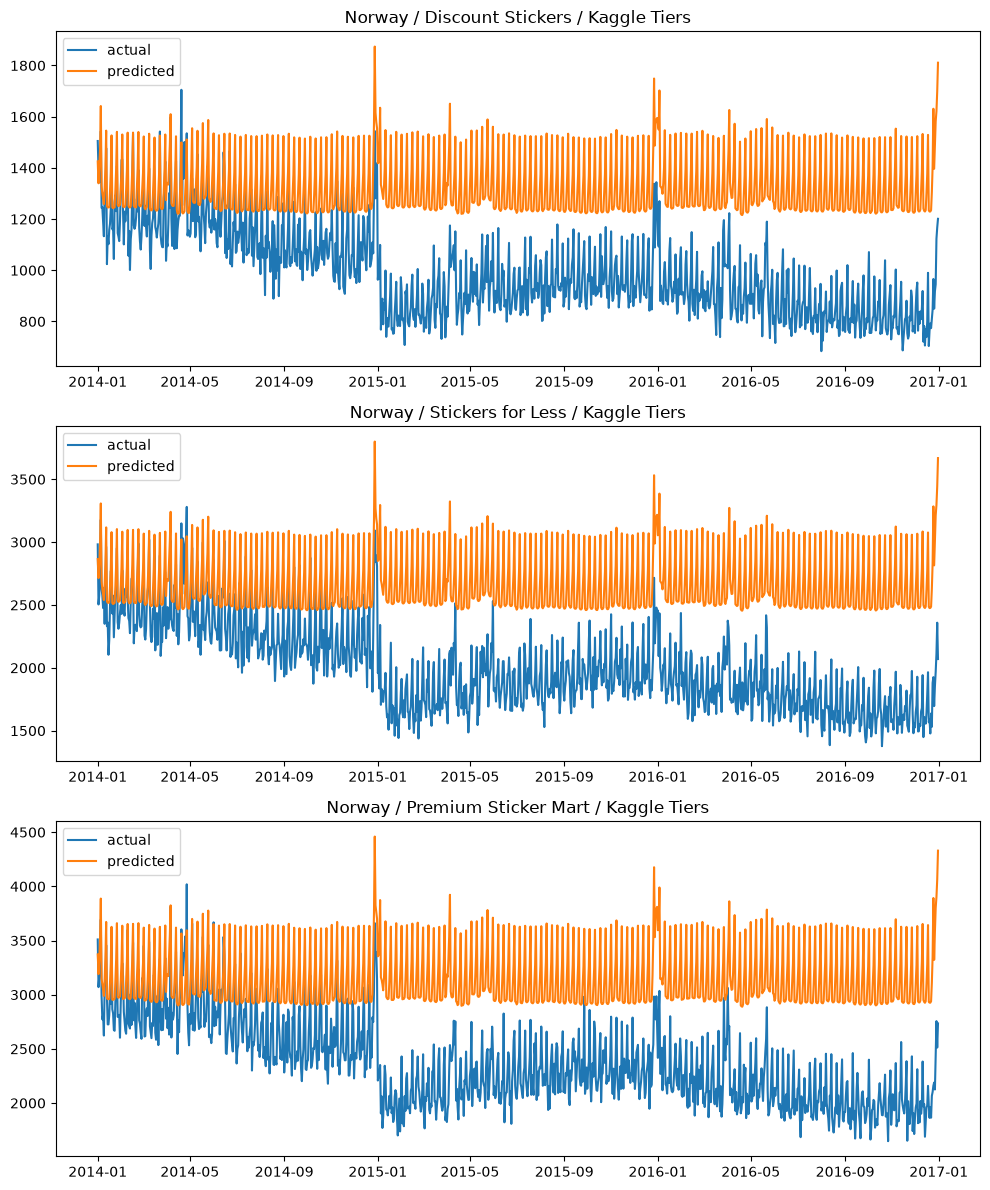

Saved plot to C:\Users\aslam\sticker-sales-forecasting\results\error_analysis_worst_series.png


In [6]:
val_plot = long_val[["date", "country", "store", "product"]].copy()
val_plot["y_true"] = y_true
val_plot["y_pred"] = v3_predictions
val_plot["abs_pct_err"] = (val_plot["y_true"] - val_plot["y_pred"]).abs() / val_plot["y_true"] * 100

worst_series = (
    val_plot.groupby(["country", "store", "product"])["abs_pct_err"]
    .mean()
    .sort_values(ascending=False)
    .head(3)
)
print("Worst 3 series by mean absolute %% error:")
print(worst_series)

fig, axes = plt.subplots(len(worst_series), 1, figsize=(10, 4 * len(worst_series)))
if len(worst_series) == 1:
    axes = [axes]

for ax, (key, _) in zip(axes, worst_series.items()):
    country, store, product = key
    sub = val_plot[
        (val_plot["country"] == country)
        & (val_plot["store"] == store)
        & (val_plot["product"] == product)
    ].sort_values("date")
    ax.plot(sub["date"], sub["y_true"], label="actual")
    ax.plot(sub["date"], sub["y_pred"], label="predicted")
    ax.set_title(f"{country} / {store} / {product}")
    ax.legend()

fig.tight_layout()
fig.savefig(RESULTS_DIR / "error_analysis_worst_series.png", dpi=150)
plt.show()
print(f"Saved plot to {RESULTS_DIR / 'error_analysis_worst_series.png'}")


## 7. Conclusions

*(Fill in after reading the tables/plot above, e.g.: which country/store/product
combinations the final model still struggles with relative to
seasonal_naive_last_year, whether the error grows across 2014 -> 2015 -> 2016,
and whether the worst series are related to the missing-target rows noted in
01_eda.ipynb, i.e. Holographic Goose for Canada and Kenya.)*